# GDELT news-tone toolkit — for the Lloyds SME lead-scoring pipeline

Turns **GDELT news coverage** into two signals — **tone (sentiment)** = *how* a topic is talked
about, and **volume (attention)** = *how much* it is covered. In the wider project these become a
**sector × region-level feature** that sits beside the Companies House features feeding the
lead-scoring model.

> ⚠️ GDELT only covers *news*, and individual SMEs are almost never in the news. So this is a
> **sector / region climate** signal (join to each firm by SIC group + region) — **not** a
> per-company one.

## Two routes — pick by scale

| | **DOC API** (Part 1) | **BigQuery / GKG** (Parts 2–4) |
|---|---|---|
| Best for | **one theme**, quick / ad-hoc | **many themes / sectors** at once |
| Matching | exact free-text keywords | GKG **theme names** (approximate) |
| Geography | source country only | real **`V2Locations`** (UK regions) |
| History | ~1 year | full (2015 → now) |
| Limit to watch | per-IP **rate limit (429)** | **bytes scanned** (cost) |
| Setup | none (free & keyless) | GCP project + auth |

**Rule of thumb:** *single theme / no cloud* → DOC API · *many sectors, geography, or long history* → BigQuery.

### Contents
1. **Part 1 — DOC API:** robust client + a single-theme **tone & volume** example.
2. **Part 2 — BigQuery:** the same single theme — full history + real UK-region geography, **tone & volume** (Query A, Query B).
3. **Part 3 — BigQuery:** all sectors in one scan — funding-sentiment **tone & volume z-scores**.
4. **Part 4 — BigQuery:** sector **×** region wired together — the **joinable context-media index** (per-cell point-in-time z-scores, sector-only fallback for thin cells).
5. **Part 5 — postcodes.io:** company postcode → **town + region**, the join key that connects each SME to the Part 4 index.

---

## Part 1 · DOC API — single theme, cloud-free

The DOC 2.0 API is **free and keyless.** Its one real catch is **rate limiting**: GDELT throttles **per IP** to
~1 request / 5 s, and a burst drops your IP into an **extended penalty box** (minutes) that returns
`HTTP 429`. The client in the next cells handles this so a run won't just crash:

1. a **global throttle** — a minimum gap before *every* request, even across cells;
2. **exponential backoff + jitter** on 429, plus a `cooldown()` helper for the deep penalty box;
3. robust handling of GDELT's quirks (plain-text errors behind HTTP 200, empty bodies, the
   mandatory browser User-Agent).

Sources: [DOC 2.0 API](https://blog.gdeltproject.org/gdelt-doc-2-0-api-debuts/) ·
[API quotas](https://blog.gdeltproject.org/behind-the-scenes-api-quotas-the-impact-of-a-fraction-of-a-qps/) ·
[User-Agent fix](https://github.com/alex9smith/gdelt-doc-api/issues/22)

In [11]:
import os, time, random, threading
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
# ---------------------------------------------------------------------------
# Robust GDELT DOC 2.0 client
# ---------------------------------------------------------------------------
DOC_BASE = "https://api.gdeltproject.org/api/v2/doc/doc"

# A real browser User-Agent is MANDATORY — GDELT returns 429 to non-browser clients.
HEADERS = {
    "User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                   "AppleWebKit/537.36 (KHTML, like Gecko) "
                   "Chrome/124.0 Safari/537.36"),
    "Accept": "application/json",
}

# >>> THE LAG KNOB YOU <<<
# MIN_INTERVAL is the minimum gap enforced *before every request*, GLOBALLY and
# *across cells* (the timer lives in _LAST_CALL, which survives between cell runs).
# So two helper calls in a row (e.g. timeline_tone() then timeline_volume()) are
# already spaced by this value automatically — no manual time.sleep() needed.
# GDELT's floor is ~5 s; raise this if you still trip the limit on a clean IP.
MIN_INTERVAL = 10.0         # seconds enforced *before* every request (was 6)
_LAST_CALL = [0.0]
_LOCK = threading.Lock()


def _throttle():
    """Block until at least MIN_INTERVAL has passed since the previous request."""
    with _LOCK:
        gap = MIN_INTERVAL - (time.monotonic() - _LAST_CALL[0])
        if gap > 0:
            time.sleep(gap)
        _LAST_CALL[0] = time.monotonic()


def cooldown(minutes=15):
    """Sit idle (making NO requests) to let GDELT's per-IP penalty box expire.

    Run this cell when you keep getting 429s even on a single well-spaced call.
    Once GDELT has penalised your IP, *every* further request can prolong the
    block, so the only reliable cure is to stop calling GDELT entirely for a
    while and THEN make one request. Do not Ctrl+C a backoff and immediately
    rerun — that is what keeps you stuck.
    """
    print(f"Cooling down for {minutes} min with zero GDELT requests...")
    time.sleep(int(minutes * 60))
    _LAST_CALL[0] = 0.0  # reset throttle clock so the next call fires right away
    print("Cooldown done. Now run ONE timeline_tone() call and let it finish "
          "without interrupting it.")


def _get(params, base_url=DOC_BASE, max_retries=6, base_pause=12.0,
         max_pause=180.0, verbose=True):
    """GET a GDELT endpoint with throttling + exponential backoff and jitter.

    Handles GDELT's failure modes:
      * HTTP 429              -> rate-limited / penalty box  (retry with backoff)
      * 200 + plain-text body -> bad query or transient error
      * 200 + empty body      -> transient                  (retry)
    Raises RuntimeError with a clear message if it never succeeds.

    NOTE on 429s: GDELT can drop an IP into an *extended* penalty box (minutes)
    after a burst, and hitting it again while penalised can prolong it. The
    backoff therefore grows quickly and waits up to `max_pause` seconds between
    attempts so the penalty has time to clear rather than being repoked. Worst
    case here is ~9 min (12+24+48+96+180+180s) before giving up with a clear
    message. If you hit that wall, run cooldown() and try again later — and note
    that on a SHARED IP (corporate/uni network) the limit is consumed by everyone
    on that network, so client-side pacing alone may not be enough.
    """
    last_err = None
    for attempt in range(max_retries):
        _throttle()
        try:
            r = requests.get(base_url, params=params, headers=HEADERS, timeout=30)
        except requests.RequestException as e:
            last_err = e
            if verbose:
                print(f"  network error: {e} (attempt {attempt + 1}/{max_retries})")
            time.sleep(base_pause)
            continue

        if r.status_code == 429:
            ra = r.headers.get("Retry-After")
            if ra and ra.isdigit():
                pause = float(ra)
            else:
                pause = base_pause * (2 ** attempt)              # exponential
            pause = min(pause, max_pause) + random.uniform(0, base_pause)  # + jitter
            last_err = RuntimeError("HTTP 429 rate-limited")
            if verbose:
                print(f"  429 rate-limited; backing off {pause:.0f}s "
                      f"(attempt {attempt + 1}/{max_retries})  "
                      f"[do NOT interrupt + rerun — that prolongs the block]")
            time.sleep(pause)
            continue

        r.raise_for_status()
        ctype = r.headers.get("content-type", "")
        if "json" not in ctype:
            body = r.text.strip()
            if not body:                       # empty -> transient, retry
                last_err = RuntimeError("empty response body")
                if verbose:
                    print(f"  empty body; retrying (attempt {attempt + 1}/{max_retries})")
                time.sleep(base_pause)
                continue
            # non-empty, non-JSON -> a genuine query error; don't waste retries
            raise RuntimeError(f"GDELT rejected the query: {body[:200]}")
        return r.json()

    raise RuntimeError(
        f"GDELT still unavailable after {max_retries} attempts ({last_err}). "
        "Your IP is in GDELT's penalty box. Run cooldown(), wait, then rerun ONE "
        "cell. On a shared/corporate IP, consider BigQuery (gdelt-bq) instead."
    )

In [13]:
# ---------------------------------------------------------------------------
# Query builder + timeline helpers
# ---------------------------------------------------------------------------
def build_query(phrase=None, keyword=None, sourcecountry=None, sourcelang=None,
                theme=None, domain=None, extra=None):
    """Assemble a GDELT DOC query string from common filters.

    Region filter:
      * sourcecountry -> country the *outlet* is based in (FIPS code or name),
        e.g. "UK", "US", or "unitedkingdom". This is the DOC API's real
        geographic filter.

    NOTE: GDELT requires at least one actual search term (a phrase/keyword);
    a query made of only operators (e.g. just `sourcecountry:UK`) is rejected.
    """
    parts = []
    if phrase:
        parts.append(f'"{phrase}"')
    if keyword:
        parts.append(keyword)
    if sourcecountry:
        parts.append(f"sourcecountry:{sourcecountry}")
    if sourcelang:
        parts.append(f"sourcelang:{sourcelang}")
    if theme:
        parts.append(f"theme:{theme}")
    if domain:
        parts.append(f"domain:{domain}")
    if extra:
        parts.append(extra)
    if not (phrase or keyword):
        raise ValueError("GDELT needs at least a phrase or keyword, not only filters.")
    return " ".join(parts).strip()


def timeline_tone(query, timespan="14d", smooth=None, **extra):
    """Average-tone timeline for articles matching `query`.

    Tone runs ~ -100..+100 (most values -10..+10): negative = unfavourable
    coverage, 0 = neutral, positive = favourable. Returns DataFrame [date, tone].
    `smooth` (int) applies GDELT's moving-average smoothing over N points.
    """
    params = {"query": query, "mode": "timelinetone",
              "format": "json", "timespan": timespan, **extra}
    if smooth:
        params["timelinesmooth"] = int(smooth)
    data = _get(params)
    tl = data.get("timeline", [])
    series = tl[0].get("data", []) if tl else []
    df = pd.json_normalize(series)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
        df = df.rename(columns={"value": "tone"})[["date", "tone"]]
    return df


def timeline_volume(query, timespan="14d", **extra):
    """Daily volume-of-coverage timeline. Returns DataFrame [date, value]."""
    params = {"query": query, "mode": "timelinevol",
              "format": "json", "timespan": timespan, **extra}
    data = _get(params)
    tl = data.get("timeline", [])
    series = tl[0].get("data", []) if tl else []
    df = pd.json_normalize(series)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
    return df


def article_search(query, timespan="7d", maxrecords=25, **extra):
    """Matching articles as a DataFrame (seendate, title, domain, url, ...)."""
    params = {"query": query, "mode": "artlist", "format": "json",
              "timespan": timespan, "maxrecords": maxrecords, **extra}
    data = _get(params)
    return pd.json_normalize(data.get("articles", []))

## Part 2 · BigQuery — the same theme, but full history + real geography

Identical signals to Part 1 — **tone** (sentiment) and **volume** (attention) — run against **GKG in
BigQuery** instead of the HTTP API, so **no rate limits**, **full history (2015 → now)**, and **real
`V2Locations`** geography. Use this whenever the DOC API's rate limit gets in the way, or you need
geolocation / long history.

**This part runs two single-theme queries:**
- **Query A** — daily **tone** (emotion) *and* **volume** (attention, articles/day) for the theme —
  the `timelinetone`-equivalent; it prints average tone *and* average articles/day, and plots both.
- **Query B** — the UK **regions** the coverage is *about*, from real `V2Locations` mentions, with
  both **tone** and **mention-count** (attention) per region.

### One-time setup
1. A **GCP project** (the free **Sandbox** is fine — no card) with the **BigQuery API** enabled.
2. Auth: `gcloud auth application-default login` (local) **or** a service-account key
   (`GOOGLE_APPLICATION_CREDENTIALS`) for an automated job.
3. `pip install google-cloud-bigquery db-dtypes pandas matplotlib`
4. Set `PROJECT` in the next cell.

### Cost model — you pay by **bytes scanned**, not rows
- We query the **partitioned** table `gdelt-bq.gdeltv2.gkg_partitioned` and filter `_PARTITIONTIME`
  so only the needed days are scanned (the plain `gkg` is **3.6 TB**).
- `bq_query()` does a **free dry run first**, prints the GB it *would* scan, and **aborts if it
  exceeds `max_gb`** — nothing is billed until you're under budget. Free tier = **1 TB/month**.

### Matching note
BigQuery has no article body text, so themes are matched on GKG **theme names** (`V2Themes`) —
*approximate*, not literal words. When you need exact words, drop back to the DOC API (Part 1).

In [14]:
# --- BigQuery hybrid route: imports + client -------------------------------
# Run once:  pip install google-cloud-bigquery db-dtypes pandas matplotlib
import datetime as dt
import re
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

PROJECT = "lloyds-gdelt"   # <-- set your GCP project (billing must be enabled)

try:
    client = bigquery.Client(project=PROJECT) # opens an authenticated session tied to your project.
    print("BigQuery client ready for project:", client.project)
except Exception as e:
    client = None
    print("BigQuery client NOT ready — finish the setup steps in the markdown above.\n ",
          type(e).__name__, ":", e)

BigQuery client ready for project: lloyds-gdelt


In [15]:
# --- Config + helpers ------------------------------------------------------
GKG = "`gdelt-bq.gdeltv2.gkg_partitioned`"   # partitioned table = cheap date pruning

# Run window. For a weekly job this is "the last 7 days".
END_D   = dt.date.today()
START_D = END_D - dt.timedelta(days=7)

# Theme approximation of your free-text intent ("construction" + "funding").
# Each inner list = OR (a theme NAME contains any token); the groups are AND-ed.
# Refine these tokens against LOOKUP-GKGTHEMES.TXT, then spot-check matching URLs.
THEME_FILTERS = [
    ["INFORMATION", "TECHNOLOGY", "DIGITAL"],
    ["FUND", "SUBSID", "FINANC", "INVEST", "GRANT"],
]

# UK city -> region rollup (extend freely). Unmapped cities -> "Other / unmapped".
CITY_TO_REGION = {
    "London": "London",
    "Birmingham": "West Midlands", "Coventry": "West Midlands", "Wolverhampton": "West Midlands",
    "Leicester": "East Midlands", "Nottingham": "East Midlands", "Derby": "East Midlands",
    "Manchester": "North West", "Liverpool": "North West", "Preston": "North West", "Bolton": "North West",
    "Leeds": "Yorkshire", "Sheffield": "Yorkshire", "Bradford": "Yorkshire", "York": "Yorkshire", "Hull": "Yorkshire",
    "Newcastle": "North East", "Sunderland": "North East", "Durham": "North East", "Middlesbrough": "North East",
    "Bristol": "South West", "Plymouth": "South West", "Exeter": "South West", "Bath": "South West", "Gloucester": "South West",
    "Southampton": "South East", "Portsmouth": "South East", "Brighton": "South East", "Oxford": "South East", "Reading": "South East",
    "Norwich": "East of England", "Cambridge": "East of England", "Ipswich": "East of England", "Peterborough": "East of England",
    "Glasgow": "Scotland", "Edinburgh": "Scotland", "Aberdeen": "Scotland", "Dundee": "Scotland",
    "Cardiff": "Wales", "Swansea": "Wales", "Newport": "Wales",
    "Belfast": "Northern Ireland", "Derry": "Northern Ireland",
}


def theme_where(groups, col="V2Themes"):
    """Build a sanitized '(.. OR ..) AND (.. OR ..)' theme filter from token groups."""
    parts = []
    for grp in groups:
        ors = []
        for tok in grp:
            assert re.fullmatch(r"[A-Z0-9_]+", tok), f"bad theme token: {tok!r}"
            ors.append(f"{col} LIKE '%{tok}%'")
        parts.append("(" + " OR ".join(ors) + ")")
    return " AND ".join(parts) if parts else "TRUE"


def date_params(start_d, end_d):
    """Partition + DATE-column params for cost-pruned, inclusive date filtering."""
    return [
        bigquery.ScalarQueryParameter("pstart", "TIMESTAMP", f"{start_d} 00:00:00"),
        bigquery.ScalarQueryParameter("pend", "TIMESTAMP",
                                      f"{end_d + dt.timedelta(days=1)} 00:00:00"),
        bigquery.ScalarQueryParameter("dstart", "INT64",
                                      int(start_d.strftime('%Y%m%d')) * 1000000),
        bigquery.ScalarQueryParameter("dend", "INT64",
                                      int(end_d.strftime('%Y%m%d')) * 1000000 + 235959),
    ]


def bq_query(sql, params=None, max_gb=5.0, run=True):
    """Dry-run first (print GB scanned), abort if > max_gb, else run -> DataFrame.

    The dry run is free and is your cost seatbelt: it tells you how many GB the
    query WILL scan before a single byte is billed. max_gb is a hard ceiling.
    """
    if client is None:
        raise RuntimeError("BigQuery client not initialised — see the setup cell.")
    cfg = bigquery.QueryJobConfig(query_parameters=params or [],
                                  dry_run=True, use_query_cache=False)
    gb = client.query(sql, job_config=cfg).total_bytes_processed / 1e9
    print(f"Dry run: ~{gb:.2f} GB will be scanned (free tier = 1000 GB/month).")
    if gb > max_gb:
        raise RuntimeError(f"Query would scan {gb:.2f} GB > max_gb={max_gb}. "
                           "Tighten the date range/filters, or raise max_gb if intended.")
    if not run:
        return None
    cfg = bigquery.QueryJobConfig(query_parameters=params or [])
    return client.query(sql, job_config=cfg).to_dataframe()

## Part 3 · BigQuery — many themes at once (sector funding-sentiment)

The **many-themes** sweep: instead of one theme, score **every SIC sector in a single BigQuery scan**.
(The DOC API can't do this — one rate-limited request per sector drowns in 429s.)

**Goal:** each week, surface the sectors whose **funding/lending climate is improving** — a
sector-level signal of where SME borrowing demand may be rising (join to each firm by SIC group).

**Why a z-score, not raw averages?** Sectors have different baseline tone *and* very different
article volumes, so raw cross-sector numbers just reflect "which sectors are habitually covered
positively / heavily" + small-sample noise. So we **z-score each sector against its own history**,
which makes the scores comparable across sectors.

**Two z-scores — sentiment *and* attention:**

> `tone_z = (latest-week tone − sector's baseline mean tone) / baseline std`
> `vol_z  = (latest-week articles/day − sector's baseline mean articles/day) / baseline std`

- **`tone_z`** — is sentiment *unusually positive* for this sector right now?
- **`vol_z`** — is this sector getting *unusually much* coverage right now?

The strongest lead signal is a sector high on **both** — improving sentiment *and* rising attention.
The table is ranked by `tone_z`, with `vol_z` beside it (and a grouped bar chart) so you can spot that
combination. A minimum article count stops tiny sectors winning by luck.

> 📏 **Volume is measured per *day*, not per week.** The current week is usually *partial* (e.g. you
> run mid-week), so a raw weekly count — and its z-score — would read artificially low for *every*
> sector. Dividing by the number of days in each week removes that bias (a z-score is scale-invariant,
> so for complete weeks per-day and per-week give the same result; only the partial week is corrected).

**Cost controls in the cell:** `USE_CACHE` re-reads a saved **Parquet** file (0 GB) so you can iterate
the z-scores/plot for free; `DEV_MODE` runs a tiny 4-week window for a cheap smoke test; the dry-run
guard still applies. *(Parquet = a compact, typed, binary table file — like a faster CSV that also
remembers each column's data type.)*

⚠️ **Sector-level only** — GDELT can't see individual SMEs, so this tells you *which sectors* are
heating up, not which firms.

Dry run: ~358.55 GB will be scanned (free tier = 1000 GB/month).


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Queried BigQuery and cached 2062 rows -> 'BigQuery Cache files/sector_weekly_cache_104w.parquet'.

BigQuery — sector funding sentiment & attention, most improved this week (z-scores):

                    sector latest_week  latest_articles  latest_tone  baseline_tone  baseline_artic_day  tone_z  vol_z
          C: Manufacturing  2026-07-19              166         0.29          -0.42               229.4    1.61  -2.99
              P: Education  2026-07-19              697        -0.60          -0.90               923.8    0.85  -3.64
     I: Accommodation/Food  2026-07-19              110        -0.00          -0.25               115.6    0.42  -2.55
            A: Agriculture  2026-07-19              683        -0.83          -0.93               863.1    0.30  -3.92
              H: Transport  2026-07-19              702        -1.43          -1.51               828.0    0.20  -3.32
        R: Arts/Recreation  2026-07-19              691        -1.52          -1.58               816

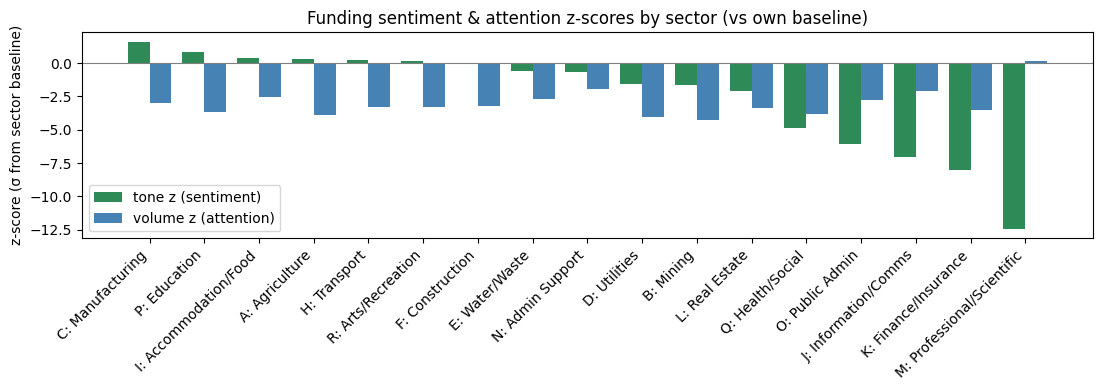

In [ ]:
# ===========================================================================
# BigQuery version — ALL sectors in one query, true article counts, baseline z
# ===========================================================================
# --- dev / cost controls (protect your 1 TB/month free tier) ---------------
USE_CACHE = True  # if a cache file exists, load it (0 GB) instead of querying
DEV_MODE  = False    # True -> tiny 4-week window for a cheap real-data smoke test

# Workflow: leave USE_CACHE=True to iterate the z-score/plot for free on cached data.
# Set USE_CACHE=False once to pull fresh data (it overwrites the cache).
# Use DEV_MODE=True for a ~13 GB smoke test; False = full ~85 GB / 26-week run.
# ---------------------------------------------------------------------------
import os

# A row can match several sectors (sectors overlap) — that's expected.
# Sector matching is on V2Themes theme-NAMES (approximate; refine vs LOOKUP-GKGTHEMES).
# Sector taxonomy = the 21 Companies House SIC SECTIONS (A-U), so these media
# z-scores key by the SAME labels build_panel()'s code_to_section() assigns to
# companies -> the media join stops missing on unmapped sectors. Patterns are GDELT
# V2Themes theme-NAME substrings (approximate; refine vs LOOKUP-GKGTHEMES). Sections
# O/T/U rarely appear in funding news -> expect thin cells (sector-only fallback).
SECTOR_PATTERNS = {                          # SIC section -> theme-name regex (lowercase)
    "A: Agriculture":              "agricultur|farming|forestry|fishing|crop|livestock",
    "B: Mining":                   "mining|quarry|coal|petroleum|extraction",
    "C: Manufacturing":            "manufactur|industrial|factory",
    "D: Utilities":                "electricity|power|energy|utilit|renewable",
    "E: Water/Waste":              "water|sewage|waste|recycling",
    "F: Construction":             "construction|infrastructure|building",
    "G: Retail/Wholesale":         "retail|wholesale|consumer goods",
    "H: Transport":                "transport|logistic|freight|shipping|aviation|railway",
    "I: Accommodation/Food":       "hospitality|tourism|restaurant|hotel|catering",
    "J: Information/Comms":         "telecom|software|information technology|media|internet",
    "K: Finance/Insurance":        "bank|financ|insurance|fintech",
    "L: Real Estate":              "real estate|property|housing",
    "M: Professional/Scientific":  "consulting|legal|accounting|engineering|research|scientific",
    "N: Admin Support":            "recruitment|staffing|outsourcing|facilities",
    "O: Public Admin":             "government|public administration|defence",
    "P: Education":                "education|school|university|training",
    "Q: Health/Social":            "health|social care|hospital|pharma",
    "R: Arts/Recreation":          "arts|entertainment|sport|recreation|gambling",
    "S: Other Services":           "repair|personal service|membership",
    "T: Household Activities":     "household|domestic",
    "U: Extraterritorial":         "international organization|diplomatic",
}
FUNDING_PAT = "fund|investment|financ|lend|loan|subsidy|grant|capital"


def _safe_pat(p):                           # allow only word chars, spaces, '|'
    assert re.fullmatch(r"[a-z0-9 |]+", p), f"unsafe pattern: {p!r}"
    return p


_sector_cte = " UNION ALL ".join(
    f"SELECT '{name}' AS sector, r'{_safe_pat(pat)}' AS pat"
    for name, pat in SECTOR_PATTERNS.items())

# Baseline length drives scan cost: ~3.3 GB/week of GKG text columns.
#   4 wk (dev) ≈ 13 GB  |  26 wk (~6 mo) ≈ 85 GB  |  53 wk (~1 yr) ≈ 174 GB.
BASE_WEEKS = 4 if DEV_MODE else 104
bq_start = END_D - dt.timedelta(weeks=BASE_WEEKS)
CACHE_DIR  = next((d for d in ("GDELT/BigQuery Cache files", "BigQuery Cache files")
                     if os.path.isdir(d)), "GDELT/BigQuery Cache files")
os.makedirs(CACHE_DIR, exist_ok=True)
CACHE_FILE = os.path.join(CACHE_DIR, f"sector_weekly_cache_{BASE_WEEKS}w.parquet")  # window-specific cache

# We also count DISTINCT days per week so volume can be read as articles/day.
# That matters because the CURRENT week is usually partial (fewer days), which
# would drag a raw weekly count — and its volume z-score — artificially low.
sql_sector = f"""
WITH sectors AS ( {_sector_cte} ),
matched AS (
  SELECT
    s.sector,
    PARSE_DATE('%Y%m%d', SUBSTR(CAST(g.DATE AS STRING), 1, 8)) AS day,
    DATE_TRUNC(PARSE_DATE('%Y%m%d', SUBSTR(CAST(g.DATE AS STRING), 1, 8)), WEEK) AS week,
    SAFE_CAST(SPLIT(g.V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64) AS tone
  FROM {GKG} g
  CROSS JOIN sectors s
  WHERE g._PARTITIONTIME >= TIMESTAMP(@pstart) AND g._PARTITIONTIME < TIMESTAMP(@pend)
    AND g.DATE >= @dstart AND g.DATE <= @dend
    AND g.V2Locations LIKE '%#UK#%'
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), r'{_safe_pat(FUNDING_PAT)}')
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), s.pat)
)
SELECT sector, week, COUNT(*) AS articles, COUNT(DISTINCT day) AS days, AVG(tone) AS avg_tone
FROM matched
GROUP BY sector, week
ORDER BY sector, week
"""

# Free re-runs: load the cache if present; otherwise query (dry-run guarded) + cache.
if USE_CACHE and os.path.exists(CACHE_FILE):
    weekly = pd.read_parquet(CACHE_FILE)
    print(f"Loaded {len(weekly)} rows from cache '{CACHE_FILE}' (0 GB scanned). "
          "Set USE_CACHE=False to pull fresh data.")
else:
    weekly = bq_query(sql_sector, params=date_params(bq_start, END_D), max_gb=400.0)
    weekly.to_parquet(CACHE_FILE)
    print(f"Queried BigQuery and cached {len(weekly)} rows -> '{CACHE_FILE}'.")

# Volume measure for the z-score = articles PER DAY (partial-week-safe).
# A z-score is scale-invariant, so per-day == per-week for full weeks; it only
# differs for the partial current week, which is exactly the bias we remove.
if "days" in weekly.columns:
    weekly["vol"] = weekly["articles"] / weekly["days"].clip(lower=1)
else:                                       # older cache (no day count) -> raw count
    weekly["vol"] = weekly["articles"]
    print("NOTE: this cache predates the per-day volume fix, so vol_z uses raw "
          "weekly counts — the latest (partial) week will read low. Re-pull with "
          "USE_CACHE=False for partial-week-safe volume z-scores.")

# Two z-scores per sector, each vs the sector's OWN baseline (so both compare
# across sectors): tone_z = is sentiment unusually positive? vol_z = is the
# sector getting unusually much coverage? Strongest lead = high on both.
MIN_ARTICLES, MIN_WEEKS = 25, 12           # min-article floor + enough baseline weeks
out = []
for sec, d in weekly.groupby("sector"):
    d = d.sort_values("week")
    latest, base = d.iloc[-1], d.iloc[:-1]      # latest week vs its own prior weeks
    enough = len(base) >= MIN_WEEKS and latest["articles"] >= MIN_ARTICLES
    tsd = base["avg_tone"].std(ddof=0)          # tone spread over the baseline
    vsd = base["vol"].std(ddof=0)               # volume (articles/day) spread
    tone_z = ((latest["avg_tone"] - base["avg_tone"].mean()) / tsd
              if enough and tsd and tsd > 0 else float("nan"))
    vol_z  = ((latest["vol"] - base["vol"].mean()) / vsd
              if enough and vsd and vsd > 0 else float("nan"))
    out.append({
        "sector": sec, "latest_week": latest["week"],
        "latest_articles": int(latest["articles"]),
        "latest_tone": round(float(latest["avg_tone"]), 2),
        "baseline_tone": round(float(base["avg_tone"].mean()), 2) if len(base) else float("nan"),
        "baseline_artic_day": round(float(base["vol"].mean()), 1) if len(base) else float("nan"),
        "tone_z": round(float(tone_z), 2) if tone_z == tone_z else float("nan"),
        "vol_z":  round(float(vol_z), 2)  if vol_z  == vol_z  else float("nan"),
    })
ranked_bq = (pd.DataFrame(out).sort_values("tone_z", ascending=False, na_position="last")
             .reset_index(drop=True))
print("\nBigQuery — sector funding sentiment & attention, most improved this week (z-scores):\n")
print(ranked_bq.to_string(index=False))

# Grouped bars: tone z (sentiment) beside volume z (attention) per sector.
r = ranked_bq.dropna(subset=["tone_z"])
if not r.empty:
    xs = list(range(len(r)))
    w = 0.4
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar([i - w / 2 for i in xs], r["tone_z"], width=w,
           label="tone z (sentiment)", color="seagreen")
    ax.bar([i + w / 2 for i in xs], r["vol_z"].fillna(0), width=w,
           label="volume z (attention)", color="steelblue")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels(r["sector"], rotation=45, ha="right")
    ax.set_ylabel("z-score (σ from sector baseline)")
    ax.set_title("Funding sentiment & attention z-scores by sector (vs own baseline)")
    ax.legend()
    plt.tight_layout(); plt.show()

## Part 4 · BigQuery — sector × region context-media index (the joinable feature)

This wires **Part 3** (all sectors, one scan) and **Query B** (`V2Locations` → UK-region rollup)
together into the project's deliverable: a weekly **(sector group, UK region)** media index that
joins to each firm by **(SIC group, region, cutoff week)**. Region is what gives the feature signal
**within** a gated single-sector lead list — every firm on that list shares the sector score, so the
regional variation is what differentiates them.

**Design points:**

- **One aggregated query**, `GROUP BY sector, region, week`. BigQuery bills by **bytes scanned**
  (columns × days), not by cells or queries, so adding region as a dimension costs ~nothing extra —
  never loop per cell.
- **Point-in-time z-scores, every week** — not just the latest. Each (sector, region, week) cell is
  scored against its **own trailing baseline** (up to 52 weeks) that **ends the week before**, so a
  value joined at a firm's cutoff week never sees the future. (With the default 26-week cache the
  trailing window is shorter; re-pull with `BASE_WEEKS = 53` for the full 52-week baseline.)
- **Thin cells fall back to sector-only.** Splitting by ~12 regions thins each cell; where a cell has
  fewer than `MIN_CELL_ARTICLES` in the week (or no usable baseline), the row takes the **sector-only
  z** from Part 3's data instead. A `z_source` column records which was used.
- **Regions stay coarse** — the same ~12 ITL1-style regions as `CITY_TO_REGION` (cities would thin
  cells into uselessness).

**Output** (also cached to Parquet): `media_index` with columns
`sector · region · week · articles · tone_z · vol_z · z_source` — ready to merge onto the
point-in-time company feature table.

**Two roles downstream:** (1) *context feature* — `tone_z` / `vol_z` joined per firm in training and
scoring; (2) the *sector gate* at scoring time still comes from Part 3's sector-level ranking.

> 💰 **Cost switch — `USE_CACHE_REGION` (this cell's own, separate from Part 3's `USE_CACHE`).**
> This is a **second ~180 GB scan**, distinct from Part 3's. It has its own switch on purpose: setting
> Part 3's `USE_CACHE=False` to refresh the sector data will **not** silently re-pull this region
> query. Leave `USE_CACHE_REGION=True` to reload the cached Parquet (0 GB); flip it to `False` only
> when you deliberately want to (re)build the region cache. The dry-run guard still applies either way.

⚠️ Run the Part 3 cell first — this cell reuses its config, its `weekly` data (for the fallback), and
its `BASE_WEEKS` / `DEV_MODE` settings.

Dry run: ~363.54 GB will be scanned (free tier = 1000 GB/month).


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Queried BigQuery and cached 18303 rows -> 'BigQuery Cache files/sector_region_weekly_cache_104w.parquet'.

Context-media index: 20333 (sector, region, week) rows -> 'BigQuery Cache files/context_media_index_104w.parquet'
Feature-table join key: (SIC group -> sector, region, cutoff week).
Sector-only fallback used on 48% of rows (a cell needs >= 10 articles and a >= 12-week baseline).


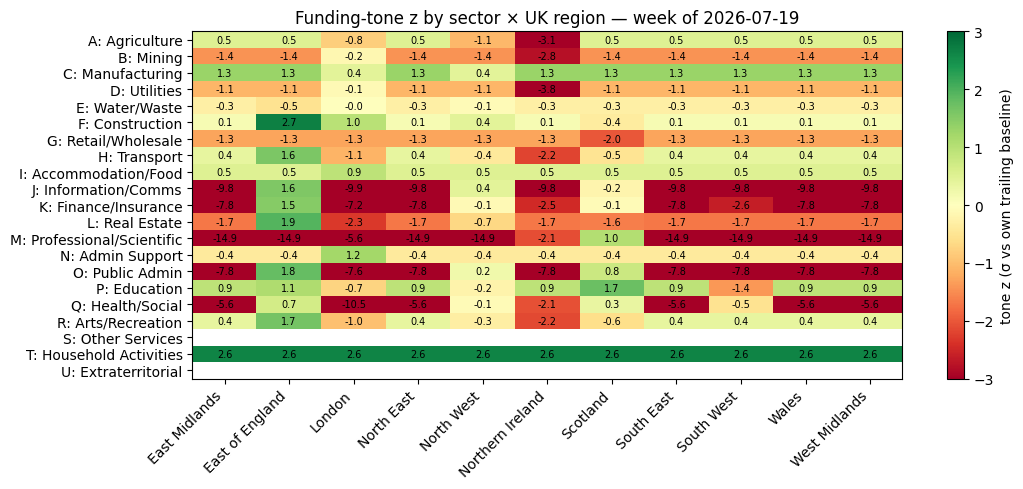

In [ ]:
# ===========================================================================
# Part 4 — sector × region × week context-media index (joinable feature table)
# ===========================================================================
# Extends Part 3's single scan with Query B's V2Locations region rollup:
# GROUP BY sector, region, week in ONE aggregated query. BigQuery bills bytes
# scanned (columns × days), so the extra GROUP BY dimension is ~free — never
# loop per cell.
# Depends on the Part 3 cell (SECTOR_PATTERNS/_sector_cte, _safe_pat,
# FUNDING_PAT, BASE_WEEKS, bq_start, MIN_WEEKS, and `weekly` for the
# sector-only fallback) — run Part 3 first.
import numpy as np

# --- Part 4's OWN cache switch (independent of Part 3's USE_CACHE) ----------
# This is a SEPARATE ~180 GB scan from Part 3. Keeping its own switch means
# flipping Part 3's USE_CACHE=False to refresh the sector data does NOT also
# silently re-pull this region query. Set THIS to False only when you
# deliberately want to (re)build the region cache.
USE_CACHE_REGION = True   # True -> load the region Parquet (0 GB) if it exists

MIN_CELL_ARTICLES = 10   # region split thins cells; below this -> sector-only fallback
MAX_BASE_WEEKS    = 52   # trailing-baseline cap (fully used only once BASE_WEEKS=53)
CACHE_DIR    = next((d for d in ("GDELT/BigQuery Cache files", "BigQuery Cache files")
                     if os.path.isdir(d)), "GDELT/BigQuery Cache files")
os.makedirs(CACHE_DIR, exist_ok=True)
REGION_CACHE = os.path.join(CACHE_DIR, f"sector_region_weekly_cache_{BASE_WEEKS}w.parquet")
INDEX_FILE   = os.path.join(CACHE_DIR, f"context_media_index_{BASE_WEEKS}w.parquet")

for _c in CITY_TO_REGION:                    # city names are interpolated into SQL
    assert re.fullmatch(r"[A-Za-z ]+", _c), f"unsafe city name: {_c!r}"
_region_cte = " UNION ALL ".join(
    f"SELECT '{c}' AS city, '{r}' AS region" for c, r in CITY_TO_REGION.items())

# Same filters as Part 3, plus: unnest V2Locations, keep UK city/ADM1 mentions,
# map city -> region in SQL. DISTINCT on GKGRECORDID so an article naming two
# cities in the SAME region counts once there (it can still appear in several
# regions/sectors — intended). Articles with only a country-level UK mention
# carry no region: absent here, but still inside Part 3's sector totals, which
# is exactly what the sector-only fallback is built from.
sql_cells = f"""
WITH sectors AS ( {_sector_cte} ),
regions AS ( {_region_cte} ),
matched AS (
  SELECT DISTINCT
    s.sector,
    r.region,
    g.GKGRECORDID AS id,
    PARSE_DATE('%Y%m%d', SUBSTR(CAST(g.DATE AS STRING), 1, 8)) AS day,
    DATE_TRUNC(PARSE_DATE('%Y%m%d', SUBSTR(CAST(g.DATE AS STRING), 1, 8)), WEEK) AS week,
    SAFE_CAST(SPLIT(g.V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64) AS tone
  FROM {GKG} g
  CROSS JOIN sectors s
  CROSS JOIN UNNEST(SPLIT(g.V2Locations, ';')) AS loc
  JOIN regions r
    ON r.city = TRIM(SPLIT(SPLIT(loc, '#')[SAFE_OFFSET(1)], ',')[SAFE_OFFSET(0)])
  WHERE g._PARTITIONTIME >= TIMESTAMP(@pstart) AND g._PARTITIONTIME < TIMESTAMP(@pend)
    AND g.DATE >= @dstart AND g.DATE <= @dend
    AND SPLIT(loc, '#')[SAFE_OFFSET(2)] = 'UK'
    AND SAFE_CAST(SPLIT(loc, '#')[SAFE_OFFSET(0)] AS INT64) >= 3
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), r'{_safe_pat(FUNDING_PAT)}')
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), s.pat)
)
SELECT sector, region, week,
       COUNT(DISTINCT id) AS articles,
       COUNT(DISTINCT day) AS days,
       AVG(tone) AS avg_tone
FROM matched
GROUP BY sector, region, week
ORDER BY sector, region, week
"""

# Scan cost ≈ Part 3 + the small GKGRECORDID column. 26 wk ≈ ~90 GB; a full
# 53-wk pull (the target 52-week baseline) ≈ ~180 GB — hence max_gb=200.
# USE_CACHE_REGION (this cell's own switch) gates the scan — NOT Part 3's USE_CACHE.
if USE_CACHE_REGION and os.path.exists(REGION_CACHE):
    cells = pd.read_parquet(REGION_CACHE)
    print(f"Loaded {len(cells)} rows from cache '{REGION_CACHE}' (0 GB scanned). "
          "Set USE_CACHE_REGION=False to pull fresh data.")
else:
    cells = bq_query(sql_cells, params=date_params(bq_start, END_D), max_gb=450.0)
    cells.to_parquet(REGION_CACHE)
    print(f"Queried BigQuery and cached {len(cells)} rows -> '{REGION_CACHE}'.")

cells["week"]  = pd.to_datetime(cells["week"])
weekly["week"] = pd.to_datetime(weekly["week"])
cells["vol"]   = cells["articles"] / cells["days"].clip(lower=1)  # partial-week-safe


def trailing_z(s, window=MAX_BASE_WEEKS, min_weeks=MIN_WEEKS):
    """Point-in-time z: each week vs the <=52 trailing weeks that END the week before."""
    base = s.shift(1)                        # baseline excludes the scored week itself
    mean = base.rolling(window, min_periods=min_weeks).mean()
    std  = base.rolling(window, min_periods=min_weeks).std(ddof=0)
    return (s - mean) / std.replace(0, np.nan)


# Complete each series over the full week grid: a missing week = zero coverage
# (real volume signal, so vol=0); tone stays NaN (no articles -> no tone).
all_weeks = pd.date_range(weekly["week"].min(), weekly["week"].max(), freq="7D")


def complete_and_z(g):
    g = g.set_index("week").reindex(all_weeks)
    g.index.name = "week"
    g["articles"] = g["articles"].fillna(0).astype(int)
    g["vol"]      = g["vol"].fillna(0.0)
    g["tone_z"]   = trailing_z(g["avg_tone"])
    g["vol_z"]    = trailing_z(g["vol"])
    return g.reset_index()


# 1) per-(sector, region) cell z-scores — every week, not just the latest,
#    because the training table joins at each firm's cutoff week.
frames = []
for (sec, reg), g in cells.groupby(["sector", "region"]):
    z = complete_and_z(g)
    z["sector"], z["region"] = sec, reg
    frames.append(z)
cell_z = pd.concat(frames, ignore_index=True)

# 2) sector-only z-scores from Part 3's `weekly` = the thin-cell fallback
sframes = []
for sec, g in weekly.groupby("sector"):
    z = complete_and_z(g)[["week", "tone_z", "vol_z"]]
    z.columns = ["week", "tone_z_sector", "vol_z_sector"]
    z["sector"] = sec
    sframes.append(z)
sector_z = pd.concat(sframes, ignore_index=True)

# 3) fall back where the cell is thin (few articles) or lacks a usable baseline
idx = cell_z.merge(sector_z, on=["sector", "week"], how="left")
thin = idx["tone_z"].isna() | (idx["articles"] < MIN_CELL_ARTICLES)
idx["z_source"] = np.where(thin, "sector-fallback", "cell")
idx["tone_z"]   = idx["tone_z"].where(~thin, idx["tone_z_sector"])
idx["vol_z"]    = idx["vol_z"].where(~thin, idx["vol_z_sector"])

media_index = (idx[["sector", "region", "week", "articles", "tone_z", "vol_z", "z_source"]]
               .dropna(subset=["tone_z", "vol_z"], how="all")
               .sort_values(["week", "sector", "region"]).reset_index(drop=True))
media_index.to_parquet(INDEX_FILE, index=False)

fb = (media_index["z_source"] == "sector-fallback").mean()
print(f"\nContext-media index: {len(media_index)} (sector, region, week) rows -> '{INDEX_FILE}'")
print("Feature-table join key: (SIC group -> sector, region, cutoff week).")
print(f"Sector-only fallback used on {fb:.0%} of rows (a cell needs >= "
      f"{MIN_CELL_ARTICLES} articles and a >= {MIN_WEEKS}-week baseline).")

# Latest-week heatmap. Within a gated single-sector list it's the REGION
# variation (one row here) that differentiates firms — that's the signal.
latest_week = media_index["week"].max()
pv = (media_index[media_index["week"] == latest_week]
      .pivot(index="sector", columns="region", values="tone_z"))
if not pv.empty:
    fig, ax = plt.subplots(figsize=(11, 5))
    im = ax.imshow(pv.values.astype(float), cmap="RdYlGn", vmin=-3, vmax=3, aspect="auto")
    ax.set_xticks(range(len(pv.columns)))
    ax.set_xticklabels(pv.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pv.index)))
    ax.set_yticklabels(pv.index)
    for i in range(pv.shape[0]):
        for j in range(pv.shape[1]):
            v = pv.values[i, j]
            if v == v:                       # skip NaN cells
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, label="tone z (σ vs own trailing baseline)")
    ax.set_title(f"Funding-tone z by sector × UK region — week of {latest_week.date()}")
    plt.tight_layout(); plt.show()

In [18]:
import os
import pandas as pd
_cache_dir = next((d for d in ("GDELT/BigQuery Cache files", "BigQuery Cache files")
                     if os.path.isdir(d)), "GDELT/BigQuery Cache files")
media_index = pd.read_parquet(os.path.join(_cache_dir, "context_media_index_104w.parquet"))
media_index[["sector", "region", "week", "tone_z", "vol_z"]]

,sector,region,week,tone_z,vol_z
0,A: Agriculture,East Midlands,2024-10-13,0.179201,-0.55543
1,A: Agriculture,East of England,2024-10-13,0.679471,-0.680058
2,A: Agriculture,London,2024-10-13,-1.361931,2.825387
3,A: Agriculture,North East,2024-10-13,-0.735703,3.461409
4,A: Agriculture,North West,2024-10-13,0.427215,-0.977347
...,...,...,...,...,...
20328,T: Household Activities,South East,2026-07-19,2.645421,-0.751828
20329,T: Household Activities,South West,2026-07-19,2.645421,-0.751828
20330,T: Household Activities,Wales,2026-07-19,2.645421,-0.751828
20331,T: Household Activities,West Midlands,2026-07-19,2.645421,-0.751828


## Part 5 · Company postcode → town + region (the join key to the media index)

Derives each firm's **region** from its **registered-office postcode** using
**[postcodes.io](https://postcodes.io)** (free, keyless, bulk ≤100/call) and writes two columns into
the CH-pipeline SME file `com_names_sme_test.csv`:

- **`town_api`** — the postcode's local-authority district (postcodes.io `admin_district`).
- **`region`** — mapped onto the **exact same 12 labels as `CITY_TO_REGION`** so it joins straight to
  the media index.

**Postcode backfill (built in).** After the CH-pipeline expansion, the *new* companies carry
`post_code` from their raw file, but the **original ~13.5k** do not (their raw files had none). This
cell first backfills their `post_code` — **free, no API** — from the earlier
`11_7_26_with_context_media.csv` (matched on `com_num`), so region is derived uniformly for the whole
population. Then bulk postcodes.io + a small **outcode fallback** for terminated/large-user postcodes.

**Region mapping.** England → ONS `region` (renaming `"Yorkshire and The Humber"` → `"Yorkshire"`);
Scotland / Wales / Northern Ireland → `country`.

> 🔁 **Idempotent:** with `FORCE_REFRESH = False` the cell skips the API entirely once `town_api` /
> `region` exist. Flip to `True` to re-pull.

⚠️ `region` is the **registered-office** region — the point-in-time location you join on.

In [1]:
# ===========================================================================
# Part 5 — enrich the SME company table with town + GDELT region (postcodes.io)
# ===========================================================================
# Adds two columns to the SME table so it can join to the Part 4 media index:
#   town_api : local-authority town from the postcode (postcodes.io admin_district)
#   region   : mapped onto the SAME 12 labels as CITY_TO_REGION / media_index
# postcodes.io is free & keyless; the bulk endpoint resolves <=100 postcodes/call.
# ROW-INCREMENTAL: resolves only rows still missing `region`, so re-running fills
# gaps (e.g. companies whose post_code was just backfilled) instead of skipping.
import time
import requests
import pandas as pd
from pathlib import Path

# The CH-pipeline SME file (post-expansion). New companies carry post_code from
# their raw file; the ORIGINAL ~13.5k companies do not (their raw files had none),
# so we backfill those from the earlier context-media file before deriving region.
# --- portable paths: resolve the project root from ANY working directory ---
import sys
from pathlib import Path
_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "API").is_dir())
sys.path.insert(0, str(_ROOT))
from paths import SME_CSV, POSTCODE_BACKFILL_SRC

COMPANY_CSV = str(SME_CSV)          # the CH-pipeline SME file (post-expansion)
POSTCODE_BACKFILL_SRC = str(POSTCODE_BACKFILL_SRC)
FORCE_REFRESH = False   # True -> re-resolve region for EVERY row, not just the missing ones

# postcodes.io 'region' is England-only (ONS ITL1); Scotland/Wales/NI come via
# 'country'. Normalise BOTH onto the 12 GDELT labels (CITY_TO_REGION values) so
# the column is directly joinable to the media index.
COUNTRY_AS_REGION = {"Scotland", "Wales", "Northern Ireland"}
REGION_RENAME = {"Yorkshire and The Humber": "Yorkshire"}   # match the GDELT label


def _to_gdelt_region(region, country):
    """Map a postcodes.io (region, country) pair onto a GDELT region label."""
    if country in COUNTRY_AS_REGION:
        return country
    if region is None:
        return None
    return REGION_RENAME.get(region, region)     # England ONS names already align


def resolve_postcodes(postcodes, chunk=100, pause=0.15, session=None):
    """Bulk-resolve UK postcodes -> {postcode: (town, region)} via postcodes.io."""
    s = session or requests.Session()
    out = {}
    for i in range(0, len(postcodes), chunk):
        batch = postcodes[i:i + chunk]
        for attempt in range(4):
            try:
                r = s.post("https://api.postcodes.io/postcodes",
                           json={"postcodes": batch}, timeout=30)
                r.raise_for_status()
                break
            except requests.RequestException:
                if attempt == 3:
                    raise
                time.sleep(2 ** attempt)         # backoff on transient errors
        for item in r.json()["result"]:
            res = item["result"]
            out[item["query"]] = ((res.get("admin_district"),
                                   _to_gdelt_region(res.get("region"), res.get("country")))
                                  if res else (None, None))
        print(f"  resolved {min(i + chunk, len(postcodes))}/{len(postcodes)}", end="\r")
        time.sleep(pause)                        # be polite to the free API
    print()
    return out


def resolve_via_outcode(postcodes, district_to_region, session=None, pause=0.1):
    """Fallback for terminated / large-user postcodes: outcode -> (town, region)."""
    s = session or requests.Session()
    out = {}
    for p in postcodes:
        outcode = p.split(" ")[0]
        try:
            r = s.get(f"https://api.postcodes.io/outcodes/{outcode}", timeout=30)
        except requests.RequestException:
            continue
        if r.status_code != 200:
            continue
        res = r.json().get("result") or {}
        dists = res.get("admin_district") or []
        ctys  = res.get("country") or []
        town = dists[0] if dists else None
        country = ctys[0] if ctys else None
        region = (country if country in COUNTRY_AS_REGION
                  else next((district_to_region[d] for d in dists
                             if d in district_to_region), None))
        out[p] = (town, region)
        time.sleep(pause)
    return out


df = pd.read_csv(COMPANY_CSV, dtype=str)
for col in ("post_code", "town_api", "region"):
    if col not in df.columns:
        df[col] = pd.NA

# --- 1) backfill post_code for the ORIGINAL companies (their raw files had none) --
# Free (no API): pull post_code from the earlier context-media file, matched on
# com_num, so region can be derived for the whole expanded population.
need_pc = df["post_code"].fillna("").str.strip() == ""
if need_pc.any() and Path(POSTCODE_BACKFILL_SRC).exists():
    src = (pd.read_csv(POSTCODE_BACKFILL_SRC, dtype=str)
             .drop_duplicates("com_num").set_index("com_num")["post_code"])
    df.loc[need_pc, "post_code"] = df.loc[need_pc, "com_num"].map(src)
    got = int(df.loc[need_pc, "post_code"].notna().sum())
    print(f"backfilled post_code for {got}/{int(need_pc.sum())} companies "
          f"from '{Path(POSTCODE_BACKFILL_SRC).name}'")
elif need_pc.any():
    print(f"WARNING: {int(need_pc.sum())} companies lack post_code and the backfill "
          f"source was not found at '{POSTCODE_BACKFILL_SRC}' — check the path/cwd.")

# --- 2) resolve region for rows that still lack it (incremental & self-healing) ---
pc_key = df["post_code"].fillna("").str.strip().str.upper()
need = (pc_key != "") if FORCE_REFRESH else (df["region"].isna() & (pc_key != ""))
to_resolve = sorted(set(pc_key[need]) - {""})

if not to_resolve:
    print(f"region already complete — nothing to resolve "
          f"({df['region'].notna().sum()}/{len(df)} filled). "
          "Set FORCE_REFRESH=True to re-pull everything.")
else:
    print(f"Resolving {len(to_resolve)} unique postcodes via postcodes.io "
          f"(for {int(need.sum())} companies missing region) ...")
    mapping = resolve_postcodes(to_resolve)
    df.loc[need, "town_api"] = pc_key[need].map(lambda p: mapping.get(p, (None, None))[0])
    df.loc[need, "region"]   = pc_key[need].map(lambda p: mapping.get(p, (None, None))[1])

    # outcode fallback for postcodes the live endpoint couldn't resolve
    miss = df["region"].isna() & (pc_key != "")
    miss_pc = sorted(set(pc_key[miss]))
    if miss_pc:
        d2r = (df.dropna(subset=["town_api", "region"])
                 .drop_duplicates("town_api").set_index("town_api")["region"].to_dict())
        print(f"Outcode fallback for {len(miss_pc)} unresolved postcodes ...")
        fill = resolve_via_outcode(miss_pc, d2r)
        for i in df.index[miss]:
            town, region = fill.get(pc_key[i], (None, None))
            if pd.isna(df.at[i, "town_api"]) and town:
                df.at[i, "town_api"] = town
            if pd.isna(df.at[i, "region"]) and region:
                df.at[i, "region"] = region

    df.to_csv(COMPANY_CSV, index=False)
    print(f"Wrote '{COMPANY_CSV}' with town_api + region.")

# --- summary (runs either way) ---------------------------------------------
pc_present = df["post_code"].fillna("").str.strip() != ""
print(f"\nregion filled: {df['region'].notna().sum()}/{len(df)}  "
      f"(blank postcode: {(~pc_present).sum()}; "
      f"unresolved w/ postcode: {(df['region'].isna() & pc_present).sum()})")
print("\nCompanies per GDELT region:")
print(df["region"].value_counts(dropna=False).to_string())

Resolving 151264 unique postcodes via postcodes.io (for 298232 companies missing region) ...
  resolved 151264/151264
Outcode fallback for 745 unresolved postcodes ...
Wrote '/Users/natchalin_/Desktop/final_project/Lloyds/API/CompaniesHouse/company_data/company_sme_with_acctype/com_names_sme_test.csv' with town_api + region.

region filled: 298159/311913  (blank postcode: 13681; unresolved w/ postcode: 73)

Companies per GDELT region:
region
London              80132
South East          44022
East of England     30165
North West          29698
West Midlands       23344
South West          21958
Yorkshire           18173
East Midlands       17553
Scotland            15205
<NA>                13681
Wales                7571
North East           6366
Northern Ireland     3972
None                   73


## Part 6 · `build_panel()` — the point-in-time training panel

Assembles the **(company, cutoff-T) panel** that the model trains/validates on — one row per firm per
cutoff, with point-in-time features and a **forward label**. This supersedes the old single-snapshot
join: it does the same SIC→sector + media join, but at **several historical cutoffs** with labels.

**Per cutoff T:**
- **Eligibility** — keep firms that existed by T and had **no Lloyds charge on/before T** (existing
  customers are excluded — they can't be *acquired*).
- **Label** — `1` if the firm registered its **first Lloyds-group charge in `(T, T+horizon]`**, else `0`.
- **Point-in-time features** — `age_years` (T − incorporation), `prior_nonlloyds_charges` (non-Lloyds
  charges created ≤ T = proven prior borrowing), `sector` (SIC→group), `region`, and the media
  `tone_z` / `vol_z` joined at **week(T)**. `media_missing = 1` where no cell matched.

**Inputs** (all now on disk): the CH-pipeline SME file, `charges_history.csv` (Stage 4), and the Part 4
`media_index`. **Output** → `company_data/panel.csv`.

> ⚠️ **`age_years`, `prior_nonlloyds_charges` and the media features are true point-in-time.** The
> structural `account_type` / `accounts_overdue` are the **current** snapshot (we don't yet parse
> historical filings), so treat those as approximate until the point-in-time filing extractor lands.
> Same firm appears at multiple cutoffs → **split train/test by firm or by time, never at random.**

In [2]:
# ===========================================================================
# Part 6 — build_panel(): one row per (company, cutoff T), features + forward label
# ===========================================================================
import os
import pandas as pd
import numpy as np

# --- SIC -> the 21 Companies House SIC SECTIONS (A-U) -----------------------
# Same taxonomy as the model notebook, so EVERY company gets a section AND the
# labels match the GDELT media_index (Part 3 SECTOR_PATTERNS). This is what fixes
# most media_missing (previously ~24% of firms had no sector at all).
SIC_SECTIONS = [
    (1, 3,   "A: Agriculture"),           (5, 9,   "B: Mining"),
    (10, 33, "C: Manufacturing"),         (35, 35, "D: Utilities"),
    (36, 39, "E: Water/Waste"),           (41, 43, "F: Construction"),
    (45, 47, "G: Retail/Wholesale"),      (49, 53, "H: Transport"),
    (55, 56, "I: Accommodation/Food"),    (58, 63, "J: Information/Comms"),
    (64, 66, "K: Finance/Insurance"),     (68, 68, "L: Real Estate"),
    (69, 75, "M: Professional/Scientific"), (77, 82, "N: Admin Support"),
    (84, 84, "O: Public Admin"),          (85, 85, "P: Education"),
    (86, 88, "Q: Health/Social"),         (90, 93, "R: Arts/Recreation"),
    (94, 96, "S: Other Services"),        (97, 98, "T: Household Activities"),
    (99, 99, "U: Extraterritorial"),
]
# SIC 98 (resident property-management cos.) is officially section T (Household),
# which has ~no funding news -> media_missing. Override it to Real Estate so those
# ~4k firms keep a media signal. Empty this dict for a pure SIC_SECTIONS mapping.
SECTION_OVERRIDE = {98: "L: Real Estate"}


def code_to_section(code):
    """Map a SIC code to its Companies House SIC section label (A-U), or None."""
    try:
        div = int(str(code).strip()[:2])
    except (ValueError, TypeError):
        return None
    if div in SECTION_OVERRIDE:
        return SECTION_OVERRIDE[div]
    for lo, hi, section in SIC_SECTIONS:
        if lo <= div <= hi:
            return section
    return None


def _floor_to_week(ts):
    """Floor a date to the Sunday-starting week (matches BigQuery DATE_TRUNC WEEK)."""
    ts = pd.Timestamp(ts)
    return ts - pd.Timedelta(days=(ts.dayofweek + 1) % 7)


def build_panel(companies, charges, media_index, cutoffs,
                horizon_weeks=13, exclude_dissolved=False):
    """One row per (company, cutoff T): point-in-time features + forward label.

    label = 1 if the firm registered its FIRST Lloyds-group charge in (T, T+horizon].
    Excluded at T if it already held a Lloyds charge on/before T (existing customer)
    or did not yet exist at T. Media tone_z/vol_z are joined at week(T).

    companies: SME table (com_num, sic_code, date_of_creation, region, ...)
    charges:   charges_history.csv (com_num, created_on, is_lloyds)
    media_index: Part 4 index (sector, region, week, tone_z, vol_z, z_source)
    cutoffs:   list of cutoff dates T (strings or Timestamps)
    """
    comp = companies.copy()
    comp["date_of_creation"] = pd.to_datetime(comp["date_of_creation"], errors="coerce")
    comp["sector"] = comp["sic_code"].map(code_to_section)

    ch = charges.copy()
    ch["created_on"] = pd.to_datetime(ch["created_on"], errors="coerce")
    ch["is_lloyds"]  = ch["is_lloyds"].astype(str).str.lower().eq("true")
    ch = ch.dropna(subset=["created_on"])
    first_lloyds = ch[ch["is_lloyds"]].groupby("com_num")["created_on"].min()   # per firm
    nonlloyds    = ch[~ch["is_lloyds"]]

    mi = media_index.copy()
    mi["week"] = pd.to_datetime(mi["week"])
    media_weeks = np.sort(mi["week"].unique())      # for snap-to-nearest-prior-week

    frames = []
    for T in pd.to_datetime(list(cutoffs)):
        wk = _floor_to_week(T)
        horizon_end = T + pd.Timedelta(weeks=horizon_weeks)

        # eligible = existed by T AND no Lloyds charge on/before T
        fll = comp["com_num"].map(first_lloyds)
        eligible = (fll.isna() | (fll > T)) & comp["date_of_creation"].le(T)
        if exclude_dissolved and "company_status" in comp.columns:
            eligible &= comp["company_status"].eq("active")
        sub = comp[eligible].copy()

        # forward label: first Lloyds charge lands in (T, T+horizon]
        fll_sub = sub["com_num"].map(first_lloyds)
        sub["label"] = ((fll_sub > T) & (fll_sub <= horizon_end)).astype(int)

        # point-in-time features
        sub["age_years"] = (T - sub["date_of_creation"]).dt.days / 365.25
        pnl = nonlloyds[nonlloyds["created_on"] <= T].groupby("com_num").size()
        sub["prior_nonlloyds_charges"] = sub["com_num"].map(pnl).fillna(0).astype(int)
        sub["T"], sub["week"] = T, wk

        # media join: snap to the most recent media week AT OR BEFORE week(T)
        # (point-in-time safe; tolerates a cutoff off the index's exact week grid)
        _prior = media_weeks[media_weeks <= wk]
        use_wk = _prior.max() if len(_prior) else pd.NaT
        mslice = mi.loc[mi["week"] == use_wk, ["sector", "region", "tone_z", "vol_z", "z_source"]]
        sub = sub.merge(mslice, on=["sector", "region"], how="left")
        sub["media_missing"] = sub["tone_z"].isna().astype(int)
        frames.append(sub)

    keep = ["com_num", "name", "T", "week", "age_years", "sector", "region",
            "account_type", "accounts_overdue", "prior_nonlloyds_charges",
            "tone_z", "vol_z", "z_source", "media_missing", "label"]
    panel = pd.concat(frames, ignore_index=True)
    return panel[[c for c in keep if c in panel.columns]]


# --- run it ----------------------------------------------------------------
# --- portable paths: resolve the project root from ANY working directory ---
import sys
from pathlib import Path
_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "API").is_dir())
sys.path.insert(0, str(_ROOT))
from paths import SME_CSV, CHARGES_CSV, PANEL_CSV

PANEL_OUT = str(PANEL_CSV)
_cache_dir  = next((d for d in ("GDELT/BigQuery Cache files", "BigQuery Cache files")
                    if os.path.isdir(d)), "GDELT/BigQuery Cache files")
MEDIA_INDEX = os.path.join(_cache_dir, "context_media_index_104w.parquet")

companies   = pd.read_csv(SME_CSV, dtype=str)
charges     = pd.read_csv(CHARGES_CSV, dtype=str)
media_index = pd.read_parquet(MEDIA_INDEX)

# Cutoffs must sit inside the media window with room for the horizon after them.
# Non-overlapping = spaced by the horizon so each conversion counts once.
HORIZON_WEEKS = 13   # = cutoff spacing, so label windows tile exactly (no overlap)
CUTOFFS = ["2024-10-13", "2025-01-12", "2025-04-13", "2025-07-13",   # 7 quarterly cutoffs,
           "2025-10-12", "2026-01-11", "2026-04-12"]   # all real index weeks in the 104w window

panel = build_panel(companies, charges, media_index, CUTOFFS,
                    horizon_weeks=HORIZON_WEEKS)
panel.to_csv(PANEL_OUT, index=False)

# --- report ----------------------------------------------------------------
print(f"panel: {len(panel)} rows ({panel['com_num'].nunique()} companies x "
      f"{len(CUTOFFS)} cutoffs)  ->  '{PANEL_OUT}'")
print("\nper-cutoff rows / positives:")
print(panel.groupby("T").agg(rows=("com_num", "size"),
                             positives=("label", "sum")).to_string())
print(f"\ntotal positives: {int(panel['label'].sum())}  "
      f"(prevalence {panel['label'].mean():.2%})")
print(f"media features filled: {(panel['media_missing'] == 0).mean():.0%}  |  "
      f"sector mapped: {panel['sector'].notna().mean():.0%}")
if (panel["media_missing"] == 0).mean() < 0.20:
    print("\n⚠️  Almost no media matched — the media_index sector labels likely "
          "predate the SIC-section taxonomy. Re-pull Parts 3 & 4 to rebuild it.")
print("\nsample:")
print(panel.head(4).to_string(index=False))

panel: 2117863 rows (303919 companies x 7 cutoffs)  ->  '/Users/natchalin_/Desktop/final_project/Lloyds/API/panel.csv'

per-cutoff rows / positives:
              rows  positives
T                            
2024-10-13  298636         35
2025-01-12  301551         62
2025-04-13  303068         36
2025-07-13  303652         40
2025-10-12  303710         73
2026-01-11  303665         92
2026-04-12  303581         88

total positives: 426  (prevalence 0.02%)
media features filled: 89%  |  sector mapped: 100%

sample:
 com_num                       name          T       week  age_years                     sector region         account_type accounts_overdue  prior_nonlloyds_charges  tone_z  vol_z z_source  media_missing  label
15073164 NFLECTION ADVISORY LIMITED 2024-10-13 2024-10-13   1.163587 M: Professional/Scientific    NaN total-exemption-full            False                        0     NaN   <NA>      NaN              1      0
13522064               NFOGENIE LTD 2024-10-13 2024-10-

## Part 6c · point-in-time **filing** features → joined onto the panel

Builds leakage-safe as-of-T features from `filings_history.csv` (CH pipeline Stage 6) and merges them onto `panel.csv` by `(com_num, T)` — using only filings dated **on/before T**. Adds `n_accounts_filed`, `accounts_staleness_months`, `pct_late`, `avg_days_late`, and a `filings_missing` flag. Run **after** Stage 6 and Part 6. Re-runnable (drops prior copies of these columns before re-merging) and preserves the original `T` string so the model notebook's split is unaffected.

In [ ]:
# ===========================================================================
# Part 6c — point-in-time FILING features (leakage-safe) joined onto the panel
# ===========================================================================
# Due date approximated as made_up_date + 274 days (~9 months, private-co deadline).
# All features use only filings with date <= T (point-in-time). Missing -> impute +
# a filings_missing flag (same policy as media). Refit imputation on TRAIN in the model.
# --- portable paths: resolve the project root from ANY working directory ---
import sys
from pathlib import Path
_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "API").is_dir())
sys.path.insert(0, str(_ROOT))
from paths import FILINGS_CSV

if not os.path.exists(FILINGS_CSV):
    print(f"filings_history.csv not found -> run Stage 6 of the CH pipeline first.\n  {FILINGS_CSV}")
else:
    fil = pd.read_csv(FILINGS_CSV, dtype=str)
    fa = fil[fil["category"] == "accounts"].copy()
    fa["date"] = pd.to_datetime(fa["date"], errors="coerce")
    fa["made_up_date"] = pd.to_datetime(fa["made_up_date"], errors="coerce")
    fa = fa.dropna(subset=["date"])
    fa["due"] = fa["made_up_date"] + pd.Timedelta(days=274)     # ~9 months
    fa["days_late"] = (fa["date"] - fa["due"]).dt.days
    fa["late"] = fa["days_late"] > 0

    panel = pd.read_csv(PANEL_OUT, dtype={"com_num": str})      # PANEL_OUT from Part 6
    panel["_Tdt"] = pd.to_datetime(panel["T"])                  # keep original T string intact

    feat_frames = []
    for T in pd.to_datetime(panel["_Tdt"].unique()):
        sub = fa[fa["date"] <= T]                               # filed on/before T
        g = sub.groupby("com_num")
        mu = sub.loc[sub["made_up_date"] <= T].groupby("com_num")["made_up_date"].max()
        f = pd.DataFrame({
            "n_accounts_filed": g.size(),
            "pct_late":         g["late"].mean(),
            "avg_days_late":    g["days_late"].clip(lower=0).mean(),
        })
        f["accounts_staleness_months"] = (T - mu).dt.days / 30.44
        f["_Tdt"] = T
        feat_frames.append(f.reset_index())
    feats = pd.concat(feat_frames, ignore_index=True)

    new_cols = ["n_accounts_filed", "pct_late", "avg_days_late",
                "accounts_staleness_months", "filings_missing"]
    panel = panel.drop(columns=[c for c in new_cols if c in panel.columns], errors="ignore")
    panel = panel.merge(feats, on=["com_num", "_Tdt"], how="left").drop(columns="_Tdt")

    panel["filings_missing"] = panel["n_accounts_filed"].isna().astype(int)
    panel["n_accounts_filed"] = panel["n_accounts_filed"].fillna(0).astype(int)
    panel["pct_late"] = panel["pct_late"].fillna(0.0)
    panel["avg_days_late"] = panel["avg_days_late"].fillna(0.0)
    panel["accounts_staleness_months"] = panel["accounts_staleness_months"].fillna(
        panel["accounts_staleness_months"].median())

    panel.to_csv(PANEL_OUT, index=False)
    print(f"Added filing features -> {PANEL_OUT}")
    print(panel[new_cols].describe().round(2).to_string())
    print(f"\nfilings_missing: {panel['filings_missing'].mean():.1%} of rows "
          f"({panel.loc[panel['filings_missing']==0,'com_num'].nunique()} companies have accounts)")

## Part 7 · `build_flat()` — one row per company (look-alike design)

The non-panel dataset. **One row per SME**, label = **"has a Lloyds charge ever"** (2.70% prevalence,
~8,400 positives), features = current snapshot. Used to learn *what a Lloyds customer looks like*;
the deliverable is the high-scoring **non**-customers (§9).

Leakage rules kept: only **non-Lloyds** charges become features (Lloyds charges are the label).
Writes `API/flat.csv`. Requires **Part 5** to have run if you want `region` as a feature.

In [ ]:
# ===========================================================================
# Part 7 — build_flat(): one row per company, "ever a Lloyds customer" label
# ===========================================================================
import pandas as pd, numpy as np, os

# --- portable paths: resolve the project root from ANY working directory ---
import sys
from pathlib import Path
_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "API").is_dir())
sys.path.insert(0, str(_ROOT))
from paths import SME_CSV, CHARGES_CSV, FLAT_CSV

FLAT_OUT = str(FLAT_CSV)
ASOF     = pd.Timestamp("2026-01-01")     # features are a snapshot at this date

def build_flat(sme, charges, asof=ASOF):
    """One row per company. label = 1 if the firm has ANY Lloyds-group charge (ever).
    Features are CURRENT-snapshot; only NON-Lloyds charges are used (Lloyds = label)."""
    d = sme.copy()
    d["doc"] = pd.to_datetime(d["date_of_creation"], errors="coerce")
    d = d.dropna(subset=["doc"]).reset_index(drop=True)

    ch = charges.copy()
    ch["is_lloyds"]  = ch["is_lloyds"].astype(str).str.lower().eq("true")
    ch["created_on"] = pd.to_datetime(ch["created_on"], errors="coerce")
    ch = ch.dropna(subset=["created_on"])

    d["label"] = d["com_num"].isin(set(ch.loc[ch["is_lloyds"], "com_num"])).astype(int)

    nl = ch[~ch["is_lloyds"]]                       # non-Lloyds only -> safe as features
    g  = nl.groupby("com_num")
    d["nonlloyds_charges"]      = d["com_num"].map(g.size()).fillna(0).astype(int)
    d["has_nonlloyds_charge"]   = (d["nonlloyds_charges"] > 0).astype(int)
    d["yrs_since_nonlloyds_chg"] = ((asof - d["com_num"].map(g["created_on"].max()))
                                    .dt.days / 365.25).fillna(50).clip(upper=50)
    d["n_distinct_lenders"]     = d["com_num"].map(
        nl.groupby("com_num")["persons_entitled"].nunique()).fillna(0).astype(int)
    d["age_years"] = (asof - d["doc"]).dt.days / 365.25     # kept for DIAGNOSTICS, not modelling
    d["accounts_overdue"] = d["accounts_overdue"].map(
        {"True":1, True:1, "False":0, False:0}).fillna(0).astype(int)

    SEC = [(1,3,"A: Agriculture"),(5,9,"B: Mining"),(10,33,"C: Manufacturing"),(35,35,"D: Utilities"),
           (36,39,"E: Water/Waste"),(41,43,"F: Construction"),(45,47,"G: Retail/Wholesale"),
           (49,53,"H: Transport"),(55,56,"I: Accommodation/Food"),(58,63,"J: Information/Comms"),
           (64,66,"K: Finance/Insurance"),(68,68,"L: Real Estate"),(69,75,"M: Professional/Scientific"),
           (77,82,"N: Admin Support"),(84,84,"O: Public Admin"),(85,85,"P: Education"),
           (86,88,"Q: Health/Social"),(90,93,"R: Arts/Recreation"),(94,96,"S: Other Services"),
           (97,98,"T: Household Activities"),(99,99,"U: Extraterritorial")]
    def section(c):
        try: div = int(str(c).strip()[:2])
        except (ValueError, TypeError): return None
        if div == 98: return "L: Real Estate"
        for lo, hi, s in SEC:
            if lo <= div <= hi: return s
        return None
    d["sector"] = d["sic_code"].map(section)

    keep = ["com_num","name","sector","account_type","accounts_overdue","nonlloyds_charges",
            "has_nonlloyds_charge","yrs_since_nonlloyds_chg","n_distinct_lenders",
            "age_years","label"]
    if "region" in d.columns and d["region"].notna().mean() > 0.5:
        keep.insert(3, "region")
    else:
        print("NOTE: 'region' missing/sparse -> not included. Run Part 5 first to add it.")
    return d[keep].dropna(subset=["sector"]).reset_index(drop=True)


sme_df     = pd.read_csv(SME_CSV,
                         dtype=str, low_memory=False)
charges_df = pd.read_csv(CHARGES_CSV, dtype=str)
flat = build_flat(sme_df, charges_df)
flat.to_csv(FLAT_OUT, index=False)

print(f"flat: {len(flat):,} rows | positives {flat['label'].sum():,} "
      f"({flat['label'].mean():.2%}) -> {FLAT_OUT}")
print(f"sectors {flat['sector'].nunique()} | account_type {flat['account_type'].nunique()}")
flat.head(3)